# Simple Neural Network Classifier in PyTorch

## Overview

In this exercise you will build, train, and evaluate a **binary classification neural network** using **PyTorch**.

The business context is **customer purchase intention**: given a user's browsing behaviour on an e-commerce site, predict whether they will complete a purchase during that session.

By the end of this notebook you will have practiced:
- Loading and preprocessing a real-world tabular dataset
- Encoding categorical features and normalising numerical ones
- Building a feedforward neural network with `torch.nn.Module`
- Writing a training loop with a loss function and optimiser
- Evaluating model performance with accuracy, precision, recall, and F1-score
- Visualising training progress


## Dataset: Online Shoppers Purchasing Intention

**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset)

The dataset contains 12,330 sessions collected from an e-commerce website. Each row represents one user session and includes:

| Feature group | Examples |
|---|---|
| Page visit counts | `Administrative`, `Informational`, `ProductRelated` |
| Time spent on pages | `Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration` |
| Google Analytics metrics | `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay` |
| Session context | `Month`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` |
| Visitor type | `VisitorType` (Returning / New / Other) |
| Timing flag | `Weekend` (Boolean) |

**Target variable:** `Revenue` — `True` if the session ended in a purchase, `False` otherwise.

The dataset is **imbalanced**: roughly 84 % of sessions do not result in a purchase.

### Getting the data

Run the cell below to download the CSV directly from the UCI repository.

In [17]:
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
filename = "online_shoppers_intention.csv"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("Dataset downloaded.")
else:
    print("Dataset already present.")

Dataset already present.


## Step 1 — Imports

Import all libraries you will need for this exercise.

**You will need at minimum:**
- `pandas` and `numpy` for data handling
- `sklearn` utilities: `train_test_split`, `StandardScaler`, and classification metrics
- `torch`, `torch.nn`, `torch.optim`
- `torch.utils.data`: `TensorDataset`, `DataLoader`
- `matplotlib.pyplot` for plotting

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("All libraries imported successfully.")


All libraries imported successfully.


## Step 2 — Load and Explore the Data

Load the CSV file into a pandas DataFrame.

**Tasks:**
1. Load the dataset and display the first few rows.
2. Check the shape, column names, and data types.
3. Check for missing values.
4. Inspect the class balance: how many sessions resulted in a purchase vs. not?


In [19]:
df = pd.read_csv("online_shoppers_intention.csv")
print("Shape:", df.shape)
df.head()


Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [20]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Class Balance (count) ===")
print(df['Revenue'].value_counts())

print("\n=== Class Balance (%) ===")
print((df['Revenue'].value_counts(normalize=True) * 100).round(1).astype(str) + "%")


=== Data Types ===
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

=== Missing Values ===
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                  

## Step 3 — Preprocess the Data

The dataset contains a mix of numerical and categorical columns. You need to prepare it before passing it to a neural network.

**Tasks:**
1. **Encode categorical columns.** The columns `Month`, `VisitorType`, and `Weekend` are not numeric. Use one-hot encoding (e.g., `pd.get_dummies`) or label encoding as appropriate. Drop the original columns after encoding.
2. **Encode the target.** Convert the `Revenue` column (boolean) to integer (0/1) and separate it from the features.
3. **Split the data** into training and test sets (80 % / 20 %). Use `random_state=42` and `stratify=y` to preserve class proportions.
4. **Normalise numerical features** using `StandardScaler`. Fit the scaler on the training set only, then transform both train and test sets.

> **Why stratify?** The dataset is imbalanced. Stratified splitting ensures both train and test sets have the same proportion of positive examples as the full dataset.

In [21]:
# One-hot encode Month and VisitorType
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=False)

# Encode Weekend (bool → int)
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)

# Encode target (bool → int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

# Separate features and target
X = df_encoded.drop(columns=['Revenue'])
y = df_encoded['Revenue']

print("Features shape:", X.shape)
print("Feature columns:", list(X.columns))
print("\nTarget distribution:\n", y.value_counts())


Features shape: (12330, 28)
Feature columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other', 'VisitorType_Returning_Visitor']

Target distribution:
 Revenue
0    10422
1     1908
Name: count, dtype: int64


In [22]:
# Split — stratify preserves the 84/16 class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on training data only — never fit on test data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training set  : {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Positive rate — train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")


Training set  : 9,864 samples, 28 features
Test set      : 2,466 samples
Positive rate — train: 15.5% | test: 15.5%


## Step 4 — Create PyTorch Datasets and DataLoaders

PyTorch models consume data through `DataLoader` objects, which handle batching and shuffling automatically.

**Tasks:**
1. Convert your NumPy arrays `X_train`, `X_test`, `y_train`, `y_test` to `torch.FloatTensor` (features) and `torch.FloatTensor` (labels — keep as float for `BCELoss` compatibility).
2. Wrap each pair into a `TensorDataset`.
3. Create a `DataLoader` for the training set with `batch_size=64` and `shuffle=True`, and one for the test set with `shuffle=False`.
4. Print the number of batches in each loader to verify.

In [23]:
# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor  = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.values)
y_test_tensor  = torch.FloatTensor(y_test.values)

# Wrap features + labels into TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

# DataLoaders — training shuffled, test in order
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")


Training batches : 155
Test batches     : 39


C:\Users\jolanta.stutane\AppData\Local\Temp\ipykernel_34532\1898842897.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.values)


## Step 5 — Define the Neural Network

Build a feedforward neural network by subclassing `torch.nn.Module`.

**Architecture requirements:**
- **Input layer:** size equal to the number of features after preprocessing.
- **Hidden layer 1:** 64 neurons, ReLU activation.
- **Hidden layer 2:** 32 neurons, ReLU activation.
- **Output layer:** 1 neuron, Sigmoid activation (outputs a probability between 0 and 1).

**Tasks:**
1. Define the class `CustomerClassifier(nn.Module)` with an `__init__` method that builds the layers and a `forward` method that defines the data flow.
2. Instantiate the model and print it to verify the architecture.

> **Tip:** `nn.Sequential` can help you chain layers cleanly inside `__init__`.

In [24]:
class CustomerClassifier(nn.Module):
    def __init__(self, input_size):
        super(CustomerClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),   # input → hidden layer 1
            nn.ReLU(),
            nn.Linear(64, 32),           # hidden layer 1 → hidden layer 2
            nn.ReLU(),
            nn.Linear(32, 1),            # hidden layer 2 → output
            nn.Sigmoid()                 # output probability in [0, 1]
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]
model = CustomerClassifier(input_size)
print(model)
print(f"\nInput features         : {input_size}")
print(f"Trainable parameters   : {sum(p.numel() for p in model.parameters()):,}")


CustomerClassifier(
  (network): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Input features         : 28
Trainable parameters   : 3,969


## Step 6 — Define Loss Function and Optimiser

For binary classification with a sigmoid output, the standard choice is **Binary Cross-Entropy loss**.

**Tasks:**
1. Instantiate `nn.BCELoss()` as your loss function.
2. Instantiate `torch.optim.Adam` with a learning rate of `0.001` as your optimiser, passing `model.parameters()`.

> **Why Adam?** Adam adapts the learning rate per parameter and generally converges faster than plain SGD on tabular data.

In [25]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function :", criterion)
print("Optimiser     :", optimizer.__class__.__name__, "| lr =", optimizer.param_groups[0]['lr'])


Loss function : BCELoss()
Optimiser     : Adam | lr = 0.001


## Step 7 — Write the Training Loop

Train the model for **30 epochs**. For each epoch you should:

1. Set the model to training mode with `model.train()`.
2. Iterate over batches from `train_loader`.
3. For each batch:
   - Zero the gradients with `optimizer.zero_grad()`.
   - Run a **forward pass** to get predictions.
   - Compute the **loss**.
   - Run a **backward pass** with `loss.backward()`.
   - Update the weights with `optimizer.step()`.
4. After all batches, record the average epoch training loss.
5. Run a **validation pass** (no gradient computation) over `test_loader` and record the average test loss.
6. Print the losses every 5 epochs.

Store training and test losses in lists so you can plot them in the next step.

In [26]:
num_epochs  = 30
train_losses = []
test_losses  = []

for epoch in range(1, num_epochs + 1):

    # ── Training phase ───────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()                        # clear previous gradients
        predictions = model(X_batch).squeeze()       # forward pass
        loss = criterion(predictions, y_batch)       # compute loss
        loss.backward()                              # backward pass
        optimizer.step()                             # update weights
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation phase ─────────────────────────────────────────────────────
    model.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch).squeeze()
            loss = criterion(predictions, y_batch)
            epoch_test_loss += loss.item()

    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d}/{num_epochs}  —  Train Loss: {avg_train_loss:.4f}  |  Test Loss: {avg_test_loss:.4f}")


Epoch  5/30  —  Train Loss: 0.2368  |  Test Loss: 0.2578
Epoch 10/30  —  Train Loss: 0.2191  |  Test Loss: 0.2517
Epoch 15/30  —  Train Loss: 0.2101  |  Test Loss: 0.2533
Epoch 20/30  —  Train Loss: 0.2013  |  Test Loss: 0.2588
Epoch 25/30  —  Train Loss: 0.1960  |  Test Loss: 0.2635
Epoch 30/30  —  Train Loss: 0.1881  |  Test Loss: 0.2642


## Step 8 — Visualise Training Progress

Plot the training and test loss curves over epochs.

**Tasks:**
1. Create a line plot with epochs on the x-axis and loss on the y-axis.
2. Show both training loss and test loss on the same plot with a legend.
3. Add axis labels and a title.

> **What to look for:** If training loss decreases but test loss plateaus or rises, the model may be overfitting.

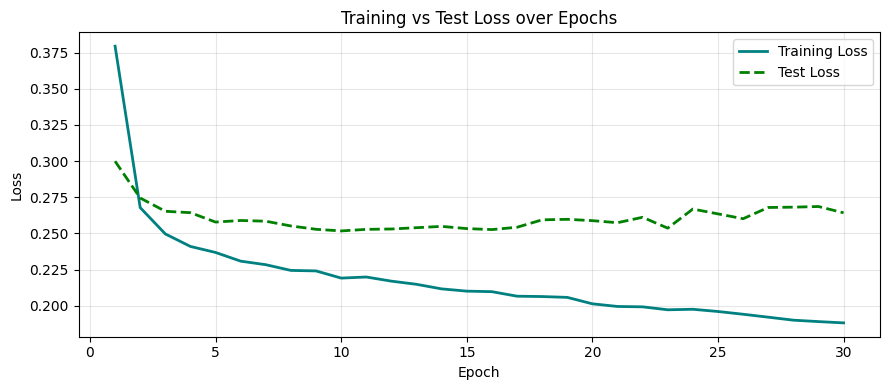

In [29]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', linewidth=2, color='teal')
plt.plot(range(1, num_epochs + 1), test_losses,  label='Test Loss',     linewidth=2, linestyle='--', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 9 — Evaluate the Model

A single accuracy number is not enough for an imbalanced dataset. Evaluate using a full set of metrics.

**Tasks:**
1. Set the model to evaluation mode with `model.eval()`.
2. Run inference over the entire test set (disable gradient tracking with `torch.no_grad()`).
3. Convert predicted probabilities to binary labels using a threshold of 0.5.
4. Compute and print:
   - **Accuracy**
   - **Precision**
   - **Recall**
   - **F1-score**
5. Print a **classification report** using `sklearn.metrics.classification_report`.

> **Tip:** Use `sklearn.metrics` functions. Remember to move tensors to CPU and convert to NumPy before passing to sklearn.

In [28]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        probs = model(X_batch).squeeze()
        preds = (probs >= 0.5).float()
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

print("=== Model Evaluation ===")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds):.4f}")
print(f"F1-score  : {f1_score(all_labels, all_preds):.4f}")
print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=['No Purchase', 'Purchase']))


=== Model Evaluation ===
Accuracy  : 0.8909
Precision : 0.6574
Recall    : 0.6178
F1-score  : 0.6370

=== Classification Report ===
              precision    recall  f1-score   support

 No Purchase       0.93      0.94      0.94      2084
    Purchase       0.66      0.62      0.64       382

    accuracy                           0.89      2466
   macro avg       0.79      0.78      0.79      2466
weighted avg       0.89      0.89      0.89      2466



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
im = axes[0].imshow(cm, interpolation='nearest', cmap='BuGn')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No Purchase', 'Purchase'])
axes[0].set_yticklabels(['No Purchase', 'Purchase'])
plt.colorbar(im, ax=axes[0])

for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

# ── Plot 2: Metrics Bar Chart ────────────────────────────────────────────────
metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-score']
metric_values = [
    accuracy_score(all_labels, all_preds),
    precision_score(all_labels, all_preds),
    recall_score(all_labels, all_preds),
    f1_score(all_labels, all_preds)
]
bar_colors = ['teal', 'green', 'steelblue', 'darkcyan']
bars = axes[1].bar(metrics, metric_values, color=bar_colors, width=0.5, edgecolor='white')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=11)
axes[1].axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='50% baseline')
axes[1].legend(fontsize=9)

for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Model Evaluation — Purchase Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
